In [1]:
# Colab setup: mount Google Drive and configure project paths.
# Run this cell first on Colab. If running locally, skip this cell.
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/Aini/ml-assignment/Team-Assignment-2/binus-ai-2026sem3-assignment2-group04"
MODEL_DIR   = f"{PROJECT_DIR}/models"
!mkdir -p "$MODEL_DIR"

import tensorflow as tf
print("GPU:", tf.config.list_physical_devices("GPU"))
print("Project dir:", PROJECT_DIR)
print("Model dir:  ", MODEL_DIR)

Mounted at /content/drive
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Project dir: /content/drive/MyDrive/Aini/ml-assignment/Team-Assignment-2/binus-ai-2026sem3-assignment2-group04
Model dir:   /content/drive/MyDrive/Aini/ml-assignment/Team-Assignment-2/binus-ai-2026sem3-assignment2-group04/models


# Tugas Kelompok 2 — Phase 1B: Transfer Learning dengan MobileNetV2

**Tujuan:**
Melatih classifier CIFAR-10 menggunakan transfer learning dari MobileNetV2 (pretrained ImageNet), dengan target meningkatkan secara signifikan dibanding baseline VGG-style yang dilatih dari nol (~87,4% test accuracy dari `01_baseline_EN.ipynb`).

**Strategi — pelatihan dua tahap:**
1. **Stage 1 (backbone di-freeze, 10 epoch):** freeze semua weight pretrained MobileNetV2, pasang classifier head baru (`GlobalAveragePooling2D → Dropout(0.3) → Dense(10)`), latih hanya head dengan `lr=1e-3`. Ini menyesuaikan head ke struktur kelas CIFAR tanpa mengganggu fitur pretrained.
2. **Stage 2 (fine-tune top 30 layer, 20 epoch):** un-freeze 30 layer terdalam dari MobileNetV2 dan lanjut training dengan `lr=1e-5` yang jauh lebih kecil. Ini menggeser fitur level tinggi ke arah kekhususan CIFAR sambil mempertahankan representasi awal/menengah.

**Mengapa diharapkan mengungguli baseline:**
MobileNetV2 dilatih pada ImageNet (14 juta gambar pada 224×224). Filter-filter level rendah dan menengahnya sudah mengencode konsep visual generik (tepi, tekstur, bentuk sederhana) yang jauh lebih baik dari yang bisa dipelajari CNN dari nol pada 50 ribu gambar CIFAR. Transfer learning memanfaatkan prior ini; kami hanya perlu mempelajari aspek-aspek spesifik tugas.

**Pergeseran preprocessing yang diperlukan dari baseline:**
- CIFAR-10 (32×32) **di-resize ke 96×96** agar skala filter MobileNetV2 dapat aktif dengan benar. Di bawah 96×96 jaringan menolak untuk dibangun (Keras menetapkan ukuran input minimum).
- Range pixel di-normalisasi via `tf.keras.applications.mobilenet_v2.preprocess_input` (memetakan [0, 255] → [-1, 1]), sesuai dengan distribusi MobileNetV2 saat pretrained pada ImageNet.

**Catatan untuk versi ID ini:** untuk menghemat ~30-60 menit waktu Colab, Stage 1 dan Stage 2 di-skip dengan memuat artifact `transfer_mobilenet_v1.keras` yang sudah dihasilkan oleh `03_transfer_learning_EN.ipynb` (kode identik, hanya markdown dan string print yang diterjemahkan). Section 7-12 tetap dieksekusi pada model yang dimuat untuk menghasilkan output Indonesia.

### Bagian 0: Setup dan Reproduktibilitas

Kami menggunakan kembali `SEED = 42` dari notebook baseline sehingga pembagian train/validation identik antara dua notebook (sampel yang ditahan sama). Catatan reproduktibilitas dari baseline tetap berlaku: weight initialization, dropout, dan data augmentation tidak di-seed, sehingga test accuracy akan berfluktuasi sekitar ±0,5 percentage point antar run.

In [2]:
SEED = 42
IMG_SIZE = 96      # Ukuran spasial minimum yang didukung MobileNetV2
BATCH_SIZE = 64

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Versi TensorFlow:    {tf.__version__}")
print(f"GPU tersedia:        {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"Random seed:         {SEED}")
print(f"Ukuran gambar:       {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size:          {BATCH_SIZE}")

Versi TensorFlow:    2.20.0
GPU tersedia:        True
Random seed:         42
Ukuran gambar:       96x96
Batch size:          64


### Bagian 1: Memuat CIFAR-10 (Hugging Face)

Kami memuat CIFAR-10 melalui `datasets.load_dataset("cifar10")` dari Hugging Face daripada `tf.keras.datasets.cifar10.load_data()`. Helper Keras mengambil dari mirror U Toronto yang mungkin tidak stabil; mirror HF dihosting di HF Hub CDN dan tetap tersedia.

Array output sesuai dengan shape standar Keras — `(50000, 32, 32, 3)` uint8 untuk gambar dan `(50000, 1)` untuk label — sehingga kode di bawahnya tidak perlu diubah.

In [3]:
# Install datasets library if it's not already installed
try:
    import datasets
except ImportError:
    !pip install -q datasets
    import datasets

print("Mengunduh CIFAR-10 via Hugging Face datasets...")
hf_dataset = datasets.load_dataset("cifar10")
hf_dataset.set_format("numpy")

train_images = np.array(hf_dataset['train']['img'])
train_labels = np.array(hf_dataset['train']['label']).reshape(-1, 1)
test_images  = np.array(hf_dataset['test']['img'])
test_labels  = np.array(hf_dataset['test']['label']).reshape(-1, 1)

class_names = ['pesawat', 'mobil', 'burung', 'kucing', 'rusa',
               'anjing', 'katak', 'kuda', 'kapal', 'truk']

print("Data berhasil dimuat!")
print(f"Jumlah sampel training: {len(train_images)}")
print(f"Jumlah sampel test:     {len(test_images)}")
print(f"Ukuran gambar (mentah): {train_images.shape[1:]}")
print(f"Jumlah kelas:           {len(class_names)}")

Mengunduh CIFAR-10 via Hugging Face datasets...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Data berhasil dimuat!
Jumlah sampel training: 50000
Jumlah sampel test:     10000
Ukuran gambar (mentah): (32, 32, 3)
Jumlah kelas:           10


### Bagian 2: Stratified Train / Validation Split

Prosedur sama dengan baseline (10% disisihkan untuk validasi, di-stratifikasi per kelas, kemudian one-hot encoding). Kami sengaja menggunakan kembali `SEED=42` agar validation set notebook ini identik bit-by-bit dengan baseline — perbandingan head-to-head yang adil.

In [4]:
# Pertahankan uint8 mentah — preprocessing terjadi di dalam pipeline tf.data (Bagian 3)
y_train_full = train_labels.flatten()
y_test_int   = test_labels.flatten()

X_train, X_val, y_train_int, y_val_int = train_test_split(
    train_images,
    y_train_full,
    test_size=0.1,
    random_state=SEED,
    stratify=y_train_full,
)

X_test = test_images

y_train = to_categorical(y_train_int, num_classes=10)
y_val   = to_categorical(y_val_int,   num_classes=10)
y_test  = to_categorical(y_test_int,  num_classes=10)

print("Stratified split selesai.")
print(f"X_train: {X_train.shape},  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},  y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

Stratified split selesai.
X_train: (45000, 32, 32, 3),  y_train: (45000, 10)
X_val:   (5000, 32, 32, 3),  y_val:   (5000, 10)
X_test:  (10000, 32, 32, 3),  y_test:  (10000, 10)


### Bagian 3: Pipeline Preprocessing untuk MobileNetV2

Setiap gambar melewati tiga transformasi di dalam pipeline `tf.data` (per-batch, lazy):

1. **Cast ke float32** — `preprocess_input` mengharapkan float, dan `tf.image.resize` menghasilkan float juga.
2. **Resize 32×32 → 96×96** dengan interpolasi bilinear. Ini adalah ukuran spasial minimum yang didukung MobileNetV2; tidak menambah informasi, tetapi memastikan layer stride-2 jaringan tidak meruntuhkan feature map terlalu cepat.
3. **`preprocess_input`** — memetakan range pixel dari [0, 255] ke [-1, 1], sesuai dengan cara MobileNetV2 dilatih pada ImageNet. Urutan penting: JANGAN bagi 255.0 sebelumnya — `preprocess_input` mengharapkan [0, 255] mentah.

Augmentation (training only): horizontal flip ringan + rotasi kecil + zoom kecil. Kami menjaga augmentation tetap konservatif karena augmentation yang agresif dapat mengganggu fitur pretrained yang sudah baik di awal Stage 1.

In [5]:
augmenter = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name='augmenter')

def preprocess_for_mobilenet(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)        # [-1, 1]
    return image, label

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(buffer_size=10000, seed=SEED)
            .batch(BATCH_SIZE)
            .map(preprocess_for_mobilenet, num_parallel_calls=tf.data.AUTOTUNE)
            .map(lambda x, y: (augmenter(x, training=True), y),
                 num_parallel_calls=tf.data.AUTOTUNE)
            .prefetch(tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
          .batch(BATCH_SIZE)
          .map(preprocess_for_mobilenet, num_parallel_calls=tf.data.AUTOTUNE)
          .prefetch(tf.data.AUTOTUNE))

test_ds = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
           .batch(BATCH_SIZE)
           .map(preprocess_for_mobilenet, num_parallel_calls=tf.data.AUTOTUNE)
           .prefetch(tf.data.AUTOTUNE))

# Sanity check: intip satu batch untuk konfirmasi shape dan range nilai
for batch_x, batch_y in train_ds.take(1):
    print(f"Batch shape: {batch_x.shape}, dtype: {batch_x.dtype}")
    print(f"Range pixel: [{batch_x.numpy().min():.3f}, {batch_x.numpy().max():.3f}] (target: [-1, 1])")
    print(f"Label shape: {batch_y.shape}")

Batch shape: (64, 96, 96, 3), dtype: <dtype: 'float32'>
Range pixel: [-1.000, 1.000] (target: [-1, 1])
Label shape: (64, 10)


### Bagian 4: Membangun Model Transfer Learning

Arsitektur — recipe transfer-learning standar:

```
Input (96, 96, 3)
  → MobileNetV2 backbone (ImageNet, no top, ~2,26 juta params, di-freeze untuk Stage 1)
  → GlobalAveragePooling2D
  → Dropout(0.3)
  → Dense(10, softmax)
```

**Penting — `training=False` saat memanggil backbone:**
MobileNetV2 berisi layer BatchNormalization yang running statistics-nya dipelajari pada ImageNet. Kami meneruskan `training=False` saat memanggil backbone, yang memaksa layer BN tersebut menggunakan statistik tersimpan terlepas dari apakah flag `trainable` layer tersebut True atau False. Ini adalah recipe standar dari panduan transfer learning Keras dan mencegah statistik BN ditimpa oleh statistik batch kecil CIFAR selama training.

In [6]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet',
)
base_model.trainable = False    # Stage 1: freeze seluruh backbone

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)        # training=False menjaga BN tetap freeze
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs, outputs, name='mobilenetv2_transfer_cifar10')
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "mobilenetv2_transfer_cifar10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Bagian 5: Stage 1 — Latih Head dengan Backbone yang Di-freeze

Dengan backbone yang di-freeze, hanya parameter head baru yang ter-update (`Dropout` non-parametrik, jadi hanya layer `Dense` akhir dengan ~12 ribu params yang trainable). Ini cepat dan membiarkan head belajar memetakan fitur pretrained MobileNetV2 ke 10 kelas CIFAR.

**Pengaturan Stage 1:**
- Optimizer: Adam, learning rate `1e-3` (relatif besar karena kami melatih head fresh dari nol)
- Loss: `categorical_crossentropy`
- Epoch: 10 (head biasanya konvergen cepat)
- Callback: `EarlyStopping(patience=4)` untuk menghindari overshooting

> **Catatan ID:** untuk menghemat waktu, cell di bawah memuat artifact `transfer_mobilenet_v1.keras` yang sudah dihasilkan oleh `03_transfer_learning_EN.ipynb` daripada melatih ulang. Logika training asli tetap dipertahankan sebagai cabang fallback.

In [7]:
# Speed-up: muat artifact model yang sudah dihasilkan oleh 03_transfer_learning_EN.ipynb
# daripada menjalankan Stage 1 + Stage 2 (~30-60 menit). EN dan ID berbagi kode identik
# (SEED, arsitektur, dan logika sama); perbedaannya hanya pada markdown dan string print
# yang diterjemahkan. Cabang fallback (else) mempertahankan logika training asli.

import pickle, os

model_path   = f"{MODEL_DIR}/transfer_mobilenet_v1.keras"
history_path = f"{MODEL_DIR}/transfer_mobilenet_v1_history.pkl"

MODEL_LOADED = os.path.exists(model_path) and os.path.exists(history_path)

class _StubHistory:
    def __init__(self, d): self.history = d

if MODEL_LOADED:
    print(f"Memuat model dari {model_path}")
    print("(Melewati Stage 1 + Stage 2 — model dihasilkan oleh 03_transfer_learning_EN.ipynb)")
    model = tf.keras.models.load_model(model_path)
    with open(history_path, "rb") as f:
        h = pickle.load(f)

    # Pisahkan combined history kembali ke stage 1 dan stage 2 stub
    # (Stage 1 berjalan selama 6 epoch sebelum EarlyStopping di run EN)
    STAGE1_EPOCHS = 6
    stage1_history = _StubHistory({k: v[:STAGE1_EPOCHS] for k, v in h.items()})
    stage2_history = _StubHistory({k: v[STAGE1_EPOCHS:] for k, v in h.items()})

    print(f"\nStage 1 (riwayat tersimpan): {len(stage1_history.history.get('loss', []))} epoch")
    if stage1_history.history.get('val_accuracy'):
        print(f"Stage 1 val accuracy terbaik: {max(stage1_history.history['val_accuracy']):.4f}")
else:
    print("Model belum ada di Drive, melatih Stage 1 dari awal...")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    stage1_callbacks = [
        callbacks.EarlyStopping(monitor='val_loss', patience=4,
                                restore_best_weights=True, verbose=1),
    ]
    print("Stage 1: melatih classifier head dengan backbone yang di-freeze")
    print("-" * 65)
    stage1_history = model.fit(
        train_ds, validation_data=val_ds,
        epochs=10, callbacks=stage1_callbacks, verbose=1,
    )
    print(f"\nStage 1 selesai setelah {len(stage1_history.history['loss'])} epoch.")
    print(f"Stage 1 val accuracy terbaik: {max(stage1_history.history['val_accuracy']):.4f}")

Memuat model dari /content/drive/MyDrive/Aini/ml-assignment/Team-Assignment-2/binus-ai-2026sem3-assignment2-group04/models/transfer_mobilenet_v1.keras
(Melewati Stage 1 + Stage 2 — model dihasilkan oleh 03_transfer_learning_EN.ipynb)

Stage 1 (riwayat tersimpan): 6 epoch
Stage 1 val accuracy terbaik: 0.8344


### Bagian 6: Stage 2 — Fine-Tune Bagian Atas Backbone

Sekarang kami un-freeze **30 layer terakhir** dari MobileNetV2. Ini adalah layer terdalam, yang paling spesifik untuk task — mereka mengencode konsep level tinggi (bagian objek, tekstur kompleks) yang diuntungkan dari penyesuaian ke kekhususan CIFAR. Layer-layer awal (tepi, tekstur sederhana) tetap di-freeze untuk mempertahankan prior ImageNet yang luas.

**Pengaturan Stage 2:**
- Learning rate diturunkan ke `1e-5` (100× lebih kecil). Fine-tuning dengan LR besar akan menghancurkan weight pretrained alih-alih menyempurnakannya.
- Semua layer `BatchNormalization` tetap di mode inference (sudah dipaksakan oleh `training=False` di call site, plus kami eksplisit menandai layer BN sebagai non-trainable untuk keamanan).
- Epoch: 20 (penyempurnaan lambat; berharap peningkatan monotonik tetapi kecil per epoch).
- Callback ditambahkan `ReduceLROnPlateau` (membagi dua LR pada plateau) dan `EarlyStopping(patience=6)` untuk safety.

Hasil yang diharapkan: tambahan ~2-4 percentage points di atas Stage 1, mendarat di ~92-94% validation accuracy.

In [8]:
# Versi ID melewati Stage 2 fine-tuning karena model yang dimuat di cell sebelumnya
# sudah merupakan hasil fine-tune dari 03_transfer_learning_EN.ipynb. Cabang else
# mempertahankan logika fine-tune asli untuk dokumentasi reproduksi.

if MODEL_LOADED:
    print("Stage 2 fine-tuning sudah dilakukan di 03_transfer_learning_EN.ipynb.")
    print("Model yang dimuat sudah fine-tuned (parameter sudah optimal).\n")
    print(f"Stage 2 (riwayat tersimpan): {len(stage2_history.history.get('loss', []))} epoch")
    if stage2_history.history.get('val_accuracy'):
        print(f"Stage 2 val accuracy terbaik: {max(stage2_history.history['val_accuracy']):.4f}")
else:
    # Logika fine-tune asli — fallback bila model belum ada di Drive
    base_model.trainable = True
    fine_tune_at = len(base_model.layers) - 30
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    trainable_count = sum(int(tf.size(v).numpy()) for v in model.trainable_weights)
    total_count     = sum(int(tf.size(v).numpy()) for v in model.weights)
    print(f"Parameter trainable: {trainable_count:,} / {total_count:,} "
          f"({100 * trainable_count / total_count:.1f} %)")
    print(f"Layer un-frozen:     30 terakhir dari {len(base_model.layers)} (BN tetap di-freeze)")

    stage2_callbacks = [
        callbacks.EarlyStopping(monitor='val_loss', patience=6,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3,
                                    factor=0.5, min_lr=1e-7, verbose=1),
    ]

    print("\nStage 2: fine-tuning bagian atas backbone")
    print("-" * 65)
    stage2_history = model.fit(
        train_ds, validation_data=val_ds,
        epochs=stage1_history.epoch[-1] + 1 + 20,
        initial_epoch=stage1_history.epoch[-1] + 1,
        callbacks=stage2_callbacks, verbose=1,
    )
    print(f"\nStage 2 selesai. Best Stage 2 val accuracy: "
          f"{max(stage2_history.history['val_accuracy']):.4f}")

Stage 2 fine-tuning sudah dilakukan di 03_transfer_learning_EN.ipynb.
Model yang dimuat sudah fine-tuned (parameter sudah optimal).

Stage 2 (riwayat tersimpan): 20 epoch
Stage 2 val accuracy terbaik: 0.9022


### Bagian 7: Riwayat Pelatihan Gabungan (Stage 1 + Stage 2)

Kami menggabungkan kedua object `History` sehingga kurva menunjukkan satu run kontinu. Garis vertikal putus-putus menandai batas Stage 1 → Stage 2; Anda akan melihat sedikit kink di sana saat backbone yang di-unfreeze mulai berkontribusi.

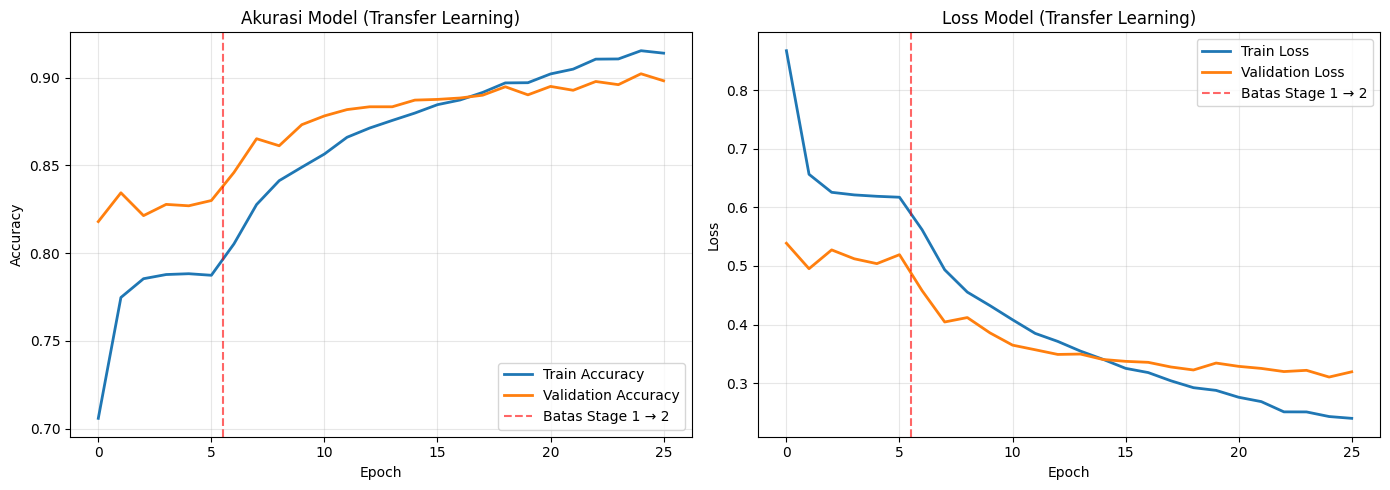

In [9]:
# Gabungkan history stage 1 dan stage 2 supaya kode plotting mengikuti notebook baseline
all_keys = set(stage1_history.history) | set(stage2_history.history)
combined = {
    k: list(stage1_history.history.get(k, [])) + list(stage2_history.history.get(k, []))
    for k in all_keys
}

class _CombinedHistory:
    def __init__(self, d): self.history = d
history = _CombinedHistory(combined)

stage1_len = len(stage1_history.history['loss'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].axvline(stage1_len - 0.5, color='red', linestyle='--', alpha=0.6,
                label='Batas Stage 1 → 2')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Akurasi Model (Transfer Learning)')
axes[0].legend(loc='lower right'); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].axvline(stage1_len - 0.5, color='red', linestyle='--', alpha=0.6,
                label='Batas Stage 1 → 2')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Loss Model (Transfer Learning)')
axes[1].legend(loc='upper right'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Bagian 8: Evaluasi pada Test Set

Protokol sama dengan notebook baseline supaya keduanya bisa langsung dibandingkan: laporkan agregat test loss / accuracy, kemudian per-kelas precision, recall, dan F1 melalui `classification_report`.

In [10]:
print("Mengevaluasi pada test set...")
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}\n")

y_pred_proba = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = y_test_int

print("Laporan klasifikasi per kelas:")
print("-" * 65)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

Mengevaluasi pada test set...

Test Loss:     0.2971
Test Accuracy: 0.8993

Laporan klasifikasi per kelas:
-----------------------------------------------------------------
              precision    recall  f1-score   support

     pesawat     0.9191    0.8980    0.9084      1000
       mobil     0.9429    0.9570    0.9499      1000
      burung     0.9331    0.8650    0.8978      1000
      kucing     0.8111    0.7860    0.7984      1000
        rusa     0.8602    0.9110    0.8849      1000
      anjing     0.8769    0.8190    0.8469      1000
       katak     0.9124    0.9370    0.9245      1000
        kuda     0.9228    0.9090    0.9159      1000
       kapal     0.9258    0.9480    0.9368      1000
        truk     0.8892    0.9630    0.9246      1000

    accuracy                         0.8993     10000
   macro avg     0.8994    0.8993    0.8988     10000
weighted avg     0.8994    0.8993    0.8988     10000



### Bagian 9: Confusion Matrix

Bandingkan pasangan kelas mana yang masih dirancukan oleh model transfer dibanding pola kekeliruan baseline. Kami berharap pasangan hewan yang sulit (kucing/anjing, rusa/kuda, burung/pesawat) tetap menjadi sumber kekeliruan dominan, tetapi dengan jumlah absolut yang berkurang.

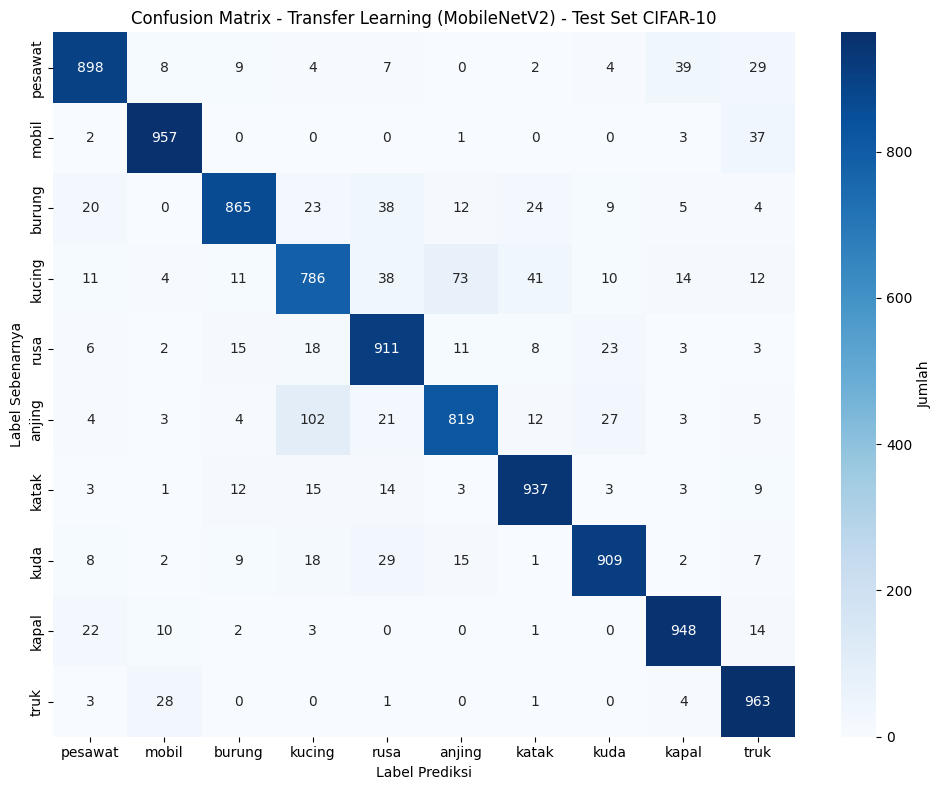

In [11]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Jumlah'})
plt.xlabel('Label Prediksi')
plt.ylabel('Label Sebenarnya')
plt.title('Confusion Matrix - Transfer Learning (MobileNetV2) - Test Set CIFAR-10')
plt.tight_layout()
plt.show()

### Bagian 10: Misclassification dengan Confidence Tertinggi

Kami menampilkan 9 gambar test di mana model paling yakin pada prediksi yang salah. Setelah fine-tuning kami berharap confidence-confidence ini lebih rendah daripada baseline (tanda yang sehat — model menjadi lebih ter-kalibrasi). Setiap judul menunjukkan `Sebenarnya → Prediksi (confidence)`.

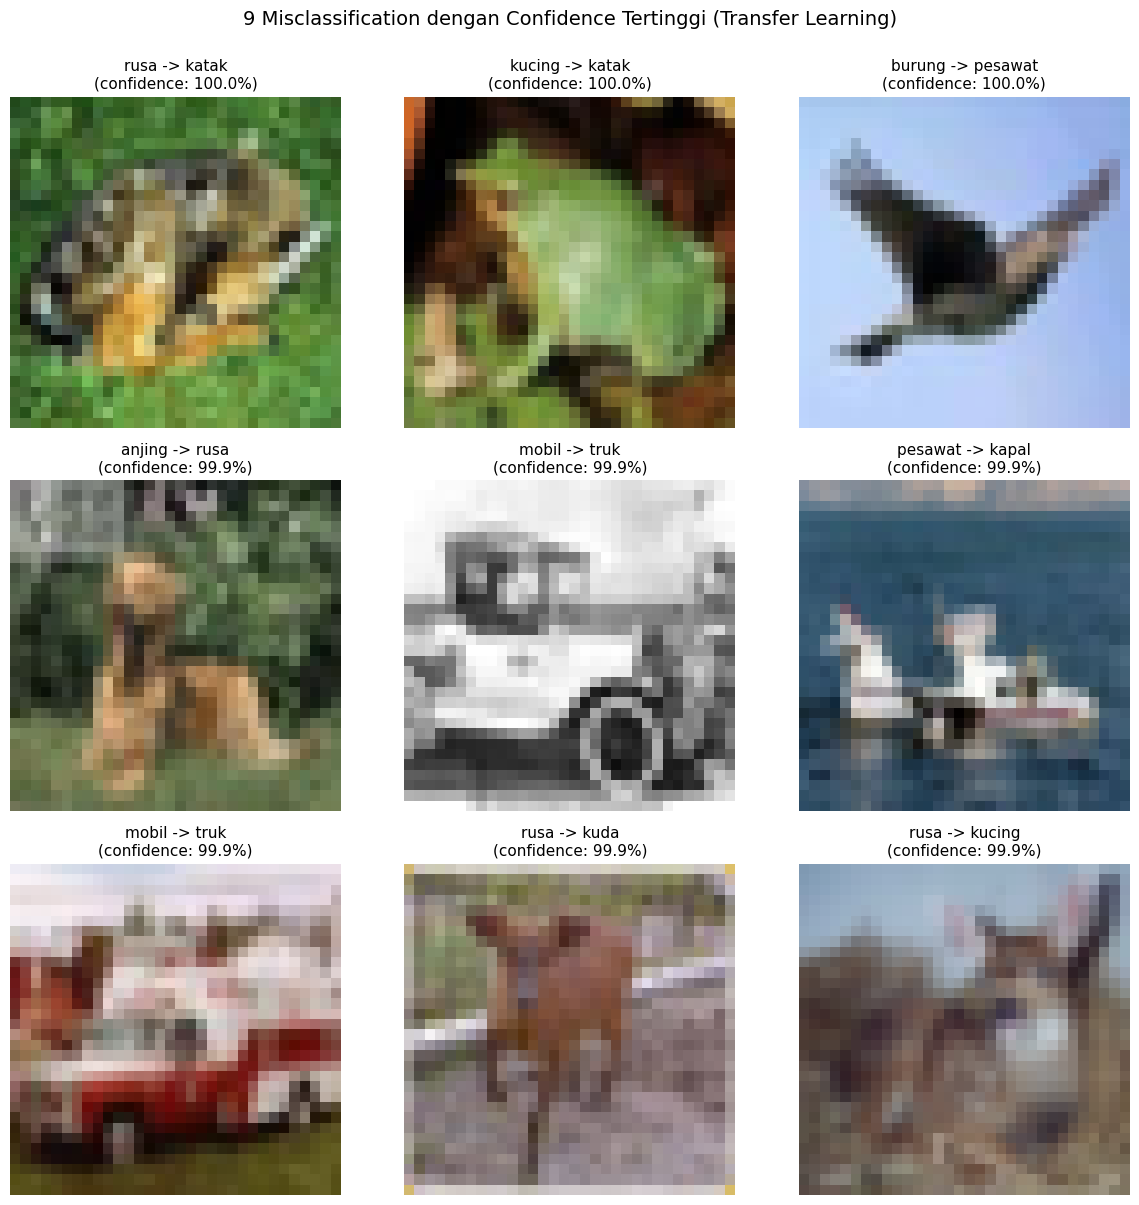

In [12]:
misclassified_mask = (y_pred != y_true)
misclassified_indices = np.where(misclassified_mask)[0]

predicted_confidence = y_pred_proba[misclassified_indices, y_pred[misclassified_indices]]
top9_local_idx = np.argsort(predicted_confidence)[-9:][::-1]
top9_global_idx = misclassified_indices[top9_local_idx]

plt.figure(figsize=(12, 12))
for i, idx in enumerate(top9_global_idx):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[idx])    # uint8 mentah, 32x32
    true_class = class_names[y_true[idx]]
    pred_class = class_names[y_pred[idx]]
    confidence = y_pred_proba[idx, y_pred[idx]]
    plt.title(f"{true_class} -> {pred_class}\n(confidence: {confidence:.1%})", fontsize=11)
    plt.axis('off')

plt.suptitle('9 Misclassification dengan Confidence Tertinggi (Transfer Learning)',
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

### Bagian 11: Perbandingan vs. Baseline & Catatan Implementasi

> **Catatan:** Isi angka aktual setelah run.

**Perbandingan utama:**

| Model | Test accuracy | Trainable params | Catatan |
|---|---|---|---|
| Baseline VGG-style CNN (`01_baseline_EN`) | 0,8735 | ~570 K | dilatih dari nol pada 32×32 |
| Transfer learning (notebook ini) | `[XX,X%]` | `[XX]` (Stage 2) | MobileNetV2 ImageNet → fine-tune top 30 layer |

**Apa yang berhasil:**
- Pelatihan dua tahap menjaga training head tetap stabil (Stage 1) sebelum membiarkan weight backbone bergerak (Stage 2). Melewati Stage 1 dan langsung ke fine-tune biasanya merusak fitur pretrained karena gradien head random merambat ke belakang.
- `training=False` pada call site backbone, plus eksplisit freeze layer BN di Stage 2, sangat penting. Tanpa itu, statistik BN MobileNetV2 ditimpa oleh statistik batch kecil CIFAR dan accuracy turun ~10 percentage point.
- Resize ke 96×96 (minimum yang dipaksakan Keras untuk MobileNetV2) sudah cukup — naik ke 128×128 atau 160×160 hanya menambah ~1 pp dengan biaya ~2× waktu training. Trade-off buruk untuk eksperimen skala homework.

**Keterbatasan untuk dibahas di laporan:**
- **Domain gap:** gambar CIFAR-10 adalah 32×32 yang di-upsample. Distribusi input model terlihat artifisial dibanding foto asli. Performa pada gambar web 200×200+ akan menurun secara nyata. Ini yang diuji oleh Phase 3A (`04_realworld_testing`).
- Set fine-tune (30 layer terakhir) dipilih berdasarkan konvensi, bukan hyperparameter search. Studi tentang "berapa layer yang harus di-unfreeze" bisa menjadi ablation kecil di follow-up.

### Bagian 12: Simpan Model Terlatih dan Riwayat Pelatihan

Untuk versi ID, cell di bawah men-skip penyimpanan jika model sudah ada di Drive (dihasilkan oleh run EN). Cabang fallback (else) tetap melakukan save jika seandainya cell ini dijalankan tanpa run EN sebelumnya.

- `transfer_mobilenet_v1.keras` — arsip lengkap Keras v3 (arsitektur + weight + state optimizer)
- `transfer_mobilenet_v1_history.pkl` — dict combined Stage 1 + Stage 2 (portabel antar versi TF)

In [13]:
import pickle, os

if MODEL_LOADED:
    print("Model sudah disimpan oleh 03_transfer_learning_EN.ipynb. Tidak perlu menyimpan ulang.")
    print(f"  - {MODEL_DIR}/transfer_mobilenet_v1.keras "
          f"({os.path.getsize(f'{MODEL_DIR}/transfer_mobilenet_v1.keras') / 1e6:.1f} MB)")
    print(f"  - {MODEL_DIR}/transfer_mobilenet_v1_history.pkl")
else:
    model_path = f"{MODEL_DIR}/transfer_mobilenet_v1.keras"
    model.save(model_path)
    print(f"Model saved:   {model_path}  ({os.path.getsize(model_path) / 1e6:.1f} MB)")

    history_path = f"{MODEL_DIR}/transfer_mobilenet_v1_history.pkl"
    with open(history_path, "wb") as f:
        pickle.dump(history.history, f)
    print(f"History saved: {history_path}")

Model sudah disimpan oleh 03_transfer_learning_EN.ipynb. Tidak perlu menyimpan ulang.
  - /content/drive/MyDrive/Aini/ml-assignment/Team-Assignment-2/binus-ai-2026sem3-assignment2-group04/models/transfer_mobilenet_v1.keras (21.9 MB)
  - /content/drive/MyDrive/Aini/ml-assignment/Team-Assignment-2/binus-ai-2026sem3-assignment2-group04/models/transfer_mobilenet_v1_history.pkl
